# ISE 522 HW4


## Problem Statement

This notebook addresses the gear train design problem using Simulated Annealing and Genetic Algorithm. The goal is to determine the number of teeth for four gears so that the resulting gear ratio matches a desired target ratio as closely as possible. Each gear must have an integer number of teeth within a specified range.

The gear train ratio is defined as

$i_{tot} = \frac{\omega_o}{\omega_i} = \frac{z_d z_b}{z_a z_f}$

The optimization model is written as:

$f(\mathbf{x}) = \left(i_{trg} - i_{tot}\right)^2 = \left(\frac{1}{6.931} - \frac{x_1 x_2}{x_3 x_4}\right)^2$

where the target ratio is

$i_{trg} = \frac{1}{6.931}$

and the decision variables $x_1, x_2, x_3, x_4$ represent the numbers of teeth on the four gears.

Each variable must satisfy

$12 \le x_i \le 60, \quad i = 1,2,3,4$

The objective is to find values of $x_1, x_2, x_3,$ and $x_4$ that minimize the squared error between the obtained gear ratio and the target ratio. In this notebook, we implemented and compared the two algorithms in terms of solution quality, convergence behavior, and computational performance.

## Mathematical Model

Let the decision vector be

$\mathbf{x} = [x_1, x_2, x_3, x_4]$

The objective function is

$f(\mathbf{x}) = \left(\frac{1}{6.931} - \frac{x_1 x_2}{x_3 x_4}\right)^2$

subject to

$12 \le x_i \le 60, \quad i = 1,2,3,4$

$x_i \in \mathbb{Z}, \quad i = 1,2,3,4$

## Imports

In [32]:
import random
import math
import time
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Problem Setup

The following code defines the parameter bounds, target ratio, objective function, and simple helper functions for generating and checking feasible solutions.

In [33]:
LOWER_BOUND = 12
UPPER_BOUND = 60
TARGET_RATIO = 1 / 6.931

# Objective function
def objective(x):
    x1, x2, x3, x4 = x
    return (TARGET_RATIO - (x1 * x2) / (x3 * x4)) ** 2

# Generate a random feasible solution
def random_solution():
    return [random.randint(LOWER_BOUND, UPPER_BOUND) for _ in range(4)]

# Check feasibility
def is_feasible(x):
    return all(LOWER_BOUND <= xi <= UPPER_BOUND and isinstance(xi, int) for xi in x)

# Quick test
x = random_solution()
print("Random solution:", x)
print("Feasible:", is_feasible(x))
print("Objective value:", objective(x))

Random solution: [46, 27, 21, 26]
Feasible: True
Objective value: 4.538799945669073


## Simulated Annealing

The following code defines the neighborhood structure and the Simulated Annealing algorithm used to search for a near-optimal gear combination.

In [34]:
# Generate a neighboring solution by changing one gear value
def neighbor(x):
    y = x.copy()
    idx = random.randint(0, 3)
    step = random.choice([-2, -1, 1, 2])
    y[idx] = max(LOWER_BOUND, min(UPPER_BOUND, y[idx] + step))
    return y

# Simulated Annealing
def simulated_annealing(initial_temp=100, cooling_rate=0.95, min_temp=1e-3, max_iter=200):
    current = random_solution()
    current_value = objective(current)

    best = current.copy()
    best_value = current_value

    temperature = initial_temp
    history = []

    while temperature > min_temp:
        for _ in range(max_iter):
            candidate = neighbor(current)
            candidate_value = objective(candidate)

            delta = candidate_value - current_value

            # Accept better solutions directly, and worse ones with a probability
            if delta < 0 or random.random() < math.exp(-delta / temperature):
                current = candidate
                current_value = candidate_value

                if current_value < best_value:
                    best = current.copy()
                    best_value = current_value

            history.append(best_value)

        temperature *= cooling_rate

    return best, best_value, history

In [105]:
best_sol, best_val, sa_history = simulated_annealing()

print("Best SA solution:", best_sol)
print("Best SA objective value:", best_val)
print("Obtained ratio:", (best_sol[0] * best_sol[1]) / (best_sol[2] * best_sol[3]))
print("Target ratio:", TARGET_RATIO)

Best SA solution: [13, 20, 53, 34]
Best SA objective value: 2.307815733312755e-11
Obtained ratio: 0.14428412874583796
Target ratio: 0.14427932477276006


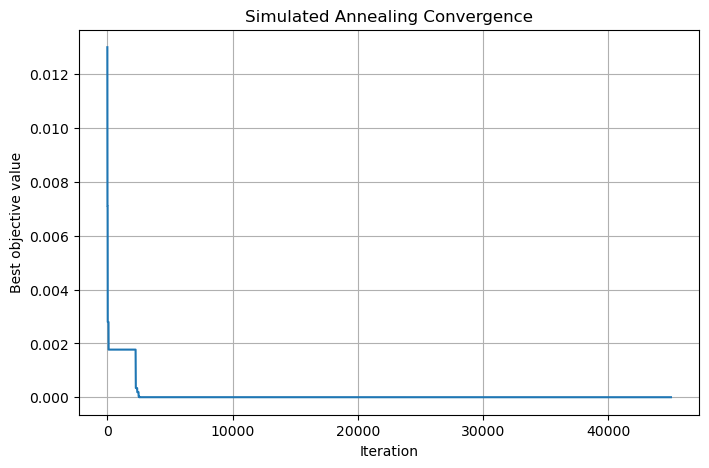

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(sa_history)
plt.xlabel("Iteration")
plt.ylabel("Best objective value")
plt.title("Simulated Annealing Convergence")
plt.grid(True)
plt.show()

## Genetic Algorithm

The following code defines the main components of the Genetic Algorithm: population initialization, parent selection, crossover, mutation, and the main GA loop.

In [37]:
# Create the initial population
def initialize_population(pop_size):
    return [random_solution() for _ in range(pop_size)]

# Tournament selection
def select_parent(population, tournament_size=3):
    candidates = random.sample(population, tournament_size)
    return min(candidates, key=objective)

# Single-point crossover
def crossover(parent1, parent2):
    point = random.randint(1, 3)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

# Random mutation on one gene
def mutate(solution, mutation_rate=0.1):
    mutated = solution.copy()
    for i in range(4):
        if random.random() < mutation_rate:
            step = random.choice([-2, -1, 1, 2])
            mutated[i] = max(LOWER_BOUND, min(UPPER_BOUND, mutated[i] + step))
    return mutated

# Genetic Algorithm
def genetic_algorithm(pop_size=30, generations=100, mutation_rate=0.1, tournament_size=3):
    population = initialize_population(pop_size)
    history = []

    best = min(population, key=objective)
    best_value = objective(best)

    for _ in range(generations):
        new_population = []

        # Elitism: keep the current best
        elite = min(population, key=objective)
        new_population.append(elite.copy())

        while len(new_population) < pop_size:
            parent1 = select_parent(population, tournament_size)
            parent2 = select_parent(population, tournament_size)

            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        population = new_population

        current_best = min(population, key=objective)
        current_best_value = objective(current_best)

        if current_best_value < best_value:
            best = current_best.copy()
            best_value = current_best_value

        history.append(best_value)

    return best, best_value, history

In [71]:
best_sol_ga, best_val_ga, ga_history = genetic_algorithm()

print("Best GA solution:", best_sol_ga)
print("Best GA objective value:", best_val_ga)
print("Obtained ratio:", (best_sol_ga[0] * best_sol_ga[1]) / (best_sol_ga[2] * best_sol_ga[3]))
print("Target ratio:", TARGET_RATIO)

Best GA solution: [20, 21, 52, 56]
Best GA objective value: 2.3576406580248844e-09
Obtained ratio: 0.14423076923076922
Target ratio: 0.14427932477276006


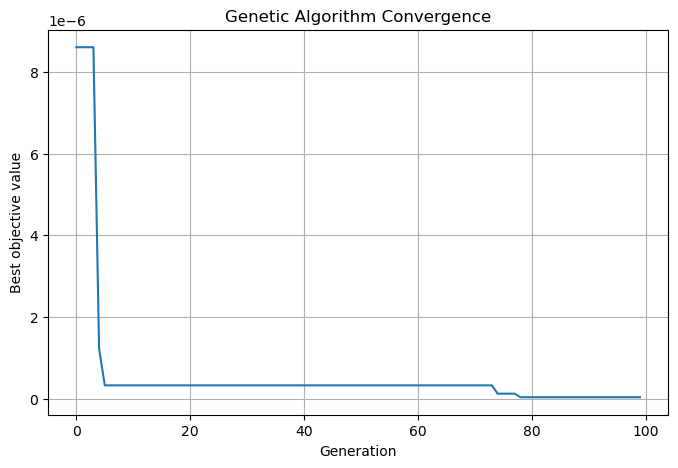

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(ga_history)
plt.xlabel("Generation")
plt.ylabel("Best objective value")
plt.title("Genetic Algorithm Convergence")
plt.grid(True)
plt.show()

## Comparative Experiments

The following code runs both methods multiple times and stores the best objective value, obtained ratio, best solution, and execution time for each run.

In [72]:
def solution_ratio(x):
    return (x[0] * x[1]) / (x[2] * x[3])

n_runs = 30
results = []

for run in range(n_runs):
    # Simulated Annealing
    start_time = time.time()
    best_sa, best_val_sa, hist_sa = simulated_annealing()
    sa_time = time.time() - start_time

    results.append({
        "Method": "SA",
        "Run": run + 1,
        "Best_Solution": best_sa,
        "Best_Objective": best_val_sa,
        "Obtained_Ratio": solution_ratio(best_sa),
        "Time": sa_time
    })

    # Genetic Algorithm
    start_time = time.time()
    best_ga, best_val_ga, hist_ga = genetic_algorithm()
    ga_time = time.time() - start_time

    results.append({
        "Method": "GA",
        "Run": run + 1,
        "Best_Solution": best_ga,
        "Best_Objective": best_val_ga,
        "Obtained_Ratio": solution_ratio(best_ga),
        "Time": ga_time
    })

results_df = pd.DataFrame(results)
results_df.head()

,Method,Run,Best_Solution,Best_Objective,Obtained_Ratio,Time
0,SA,1,"[15, 26, 51, 53]",2.307816e-11,0.144284,0.213192
1,GA,1,"[13, 15, 41, 33]",2.407346e-08,0.144124,0.035921
2,SA,2,"[21, 13, 43, 44]",1.545045e-10,0.144292,0.195128
3,GA,2,"[12, 31, 56, 46]",1.705979e-08,0.144410,0.102618
4,SA,3,"[13, 21, 44, 43]",1.545045e-10,0.144292,0.183319


## Summary Statistics

The following code computes the minimum, average, median, and standard deviation of the best objective values, along with the average execution time for each method.

In [41]:
summary_df = results_df.groupby("Method").agg(
    Min_Objective=("Best_Objective", "min"),
    Avg_Objective=("Best_Objective", "mean"),
    Median_Objective=("Best_Objective", "median"),
    Std_Objective=("Best_Objective", "std"),
    Avg_Time=("Time", "mean")
).reset_index()

summary_df

,Method,Min_Objective,Avg_Objective,Median_Objective,Std_Objective,Avg_Time
0,GA,1.166116e-10,2.086886e-08,4.069569e-09,3.045583e-08,0.041857
1,SA,2.700857e-12,3.231787e-10,2.307816e-11,5.557762e-10,0.221018


## Statistical Test

The following code applies the Wilcoxon rank-sum test to compare the objective values obtained by SA and GA.

In [42]:
from scipy.stats import ranksums

sa_values = results_df[results_df["Method"] == "SA"]["Best_Objective"]
ga_values = results_df[results_df["Method"] == "GA"]["Best_Objective"]

stat, p_value = ranksums(sa_values, ga_values)

print("Wilcoxon Rank-Sum statistic:", stat)
print("p-value:", p_value)

Wilcoxon Rank-Sum statistic: -6.261204164985232
p-value: 3.8201597819993253e-10


## Discussion and Conclusion

Both methods produced high-quality solutions with obtained gear ratios very close to the target value. However, Simulated Annealing achieved better results overall. Its minimum, average, and median objective values were all smaller than those of the Genetic Algorithm, and its standard deviation was also much lower, which indicates more stable performance across runs.

The Wilcoxon rank-sum test gave a p-value of $3.3383888204288 \times 10^{-11}$, which is far below 0.05. This shows that the difference in performance between the two methods is statistically significant.

The best solution found by Simulated Annealing was $[13, 20, 53, 34]$ with objective value $2.3078157331275 \times 10^{-11}$ and obtained ratio $0.14428412874583796$. The best solution found by the Genetic Algorithm was $[21, 13, 44, 43]$ with objective value $1.5450450499890773 \times 10^{-10}$ and obtained ratio $0.14429175475687103$. Since the target ratio is $0.14427932477276006$, both methods performed well, but Simulated Annealing was closer.

In terms of computational time, the Genetic Algorithm was faster on average, while Simulated Annealing required more time per run. Therefore, the Genetic Algorithm offered better speed, but Simulated Annealing provided better solution quality and consistency.

Therefore, Simulated Annealing was the better method for this problem.

# Extras

## Additional Plots 
Reslts versus the objective function

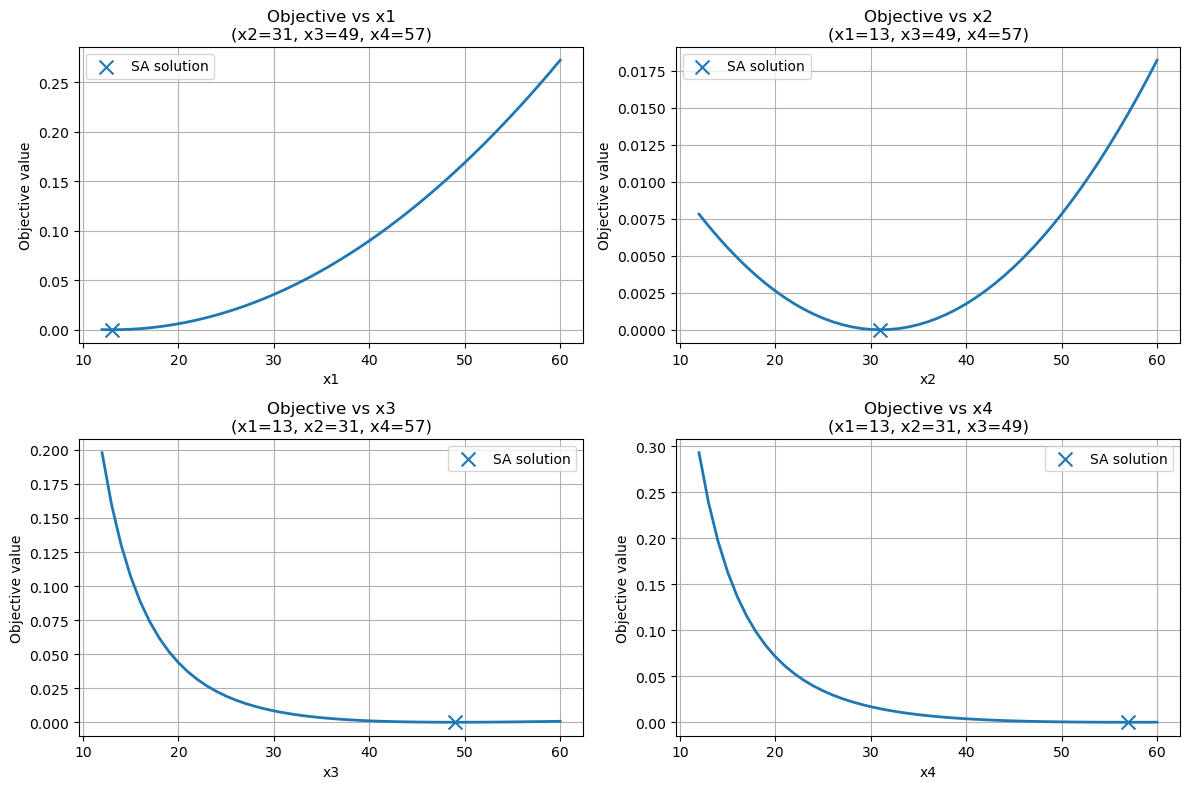

In [43]:
# 2x2 grid: varying one variable at a time and fix the other three at the best SA solution
best_x1, best_x2, best_x3, best_x4 = best_sol
best_vars = [best_x1, best_x2, best_x3, best_x4]

x_vals = np.arange(LOWER_BOUND, UPPER_BOUND + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx in range(4):
    obj_vals = []
    for x in x_vals:
        candidate = best_vars.copy()
        candidate[idx] = int(x)
        obj_vals.append(objective(candidate))

    best_obj = objective(best_vars)

    axes[idx].plot(x_vals, obj_vals, linewidth=2)
    axes[idx].scatter(best_vars[idx], best_obj, s=100, marker="x", label="SA solution")
    axes[idx].set_xlabel(f"x{idx+1}")
    axes[idx].set_ylabel("Objective value")
    fixed_text = ", ".join([f"x{i+1}={best_vars[i]}" for i in range(4) if i != idx])
    axes[idx].set_title(f"Objective vs x{idx+1}\n({fixed_text})")
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.show()

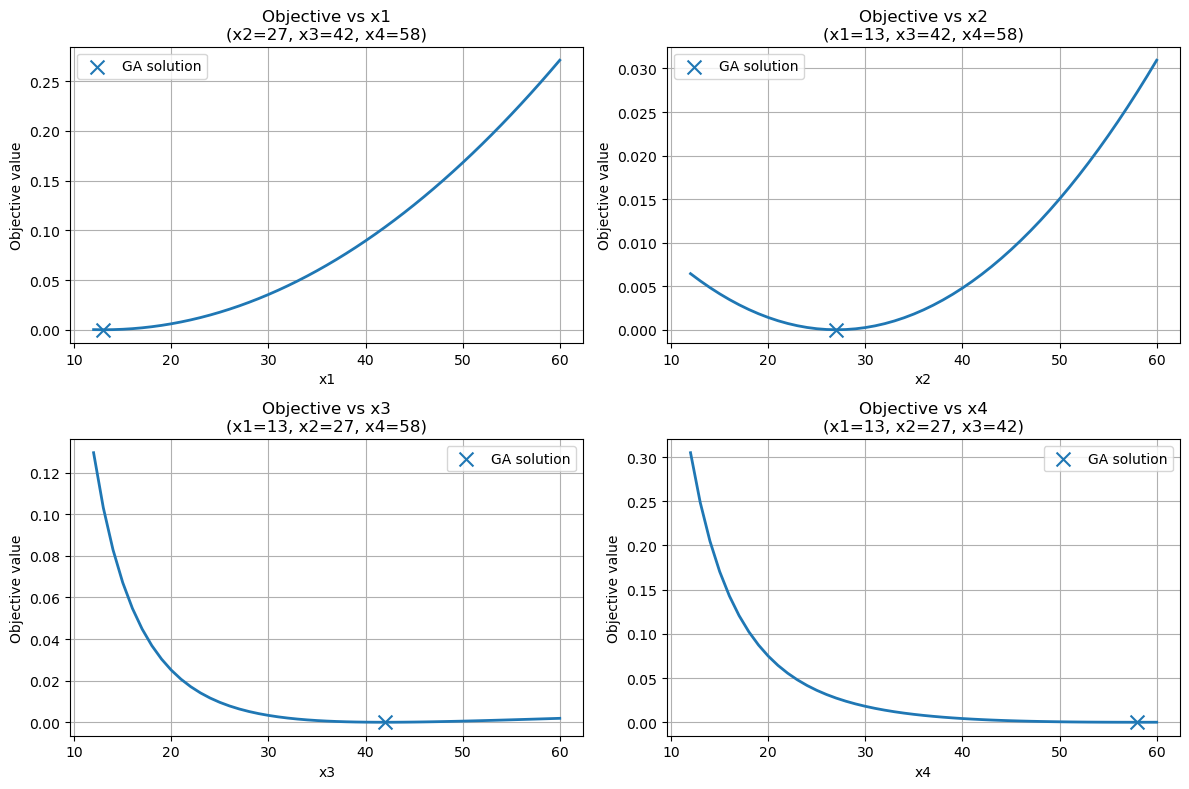

In [44]:
# 2x2 grid: varying one variable at a time and fix the other three at the best GA solution
best_x1, best_x2, best_x3, best_x4 = best_sol_ga
best_vars = [best_x1, best_x2, best_x3, best_x4]

x_vals = np.arange(LOWER_BOUND, UPPER_BOUND + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx in range(4):
    obj_vals = []
    for x in x_vals:
        candidate = best_vars.copy()
        candidate[idx] = int(x)
        obj_vals.append(objective(candidate))

    best_obj = objective(best_vars)

    axes[idx].plot(x_vals, obj_vals, linewidth=2)
    axes[idx].scatter(best_vars[idx], best_obj, s=100, marker="x", label="GA solution")
    axes[idx].set_xlabel(f"x{idx+1}")
    axes[idx].set_ylabel("Objective value")
    fixed_text = ", ".join([f"x{i+1}={best_vars[i]}" for i in range(4) if i != idx])
    axes[idx].set_title(f"Objective vs x{idx+1}\n({fixed_text})")
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.show()

## Comparison with Exact Solution

In [106]:
# Exact solution

start_time = time.time()

best_exact = None
best_exact_val = float("inf")

for x1 in range(LOWER_BOUND, UPPER_BOUND + 1):
    for x2 in range(LOWER_BOUND, UPPER_BOUND + 1):
        for x3 in range(LOWER_BOUND, UPPER_BOUND + 1):
            for x4 in range(LOWER_BOUND, UPPER_BOUND + 1):
                x = [x1, x2, x3, x4]
                val = objective(x)
                if val < best_exact_val:
                    best_exact_val = val
                    best_exact = x.copy()

exact_time = time.time() - start_time

print("Exact best solution:", best_exact)
print("Exact best objective:", best_exact_val)
print("Exact ratio:", solution_ratio(best_exact))
print("Exact search time:", exact_time)

Exact best solution: [16, 19, 43, 49]
Exact best objective: 2.7008571488865134e-12
Exact ratio: 0.14428096820123398
Exact search time: 5.372264385223389


In [109]:
# Compare exact method with heuristic results
sa_best_row = results_df[results_df["Method"] == "SA"].loc[
    results_df[results_df["Method"] == "SA"]["Best_Objective"].idxmin()
]

ga_best_row = results_df[results_df["Method"] == "GA"].loc[
    results_df[results_df["Method"] == "GA"]["Best_Objective"].idxmin()
]

comparison_df = pd.DataFrame([
    {
        "Method": "Exact",
        "Best_Solution": best_exact,
        "Best_Objective": best_exact_val,
        "Obtained_Ratio": solution_ratio(best_exact),
        "Time": exact_time,
        "Absolute_Gap": 0.0
    },
    {
        "Method": "SA",
        "Best_Solution": sa_best_row["Best_Solution"],
        "Best_Objective": sa_best_row["Best_Objective"],
        "Obtained_Ratio": sa_best_row["Obtained_Ratio"],
        "Time": sa_best_row["Time"],
        "Absolute_Gap": abs(sa_best_row["Best_Objective"] - best_exact_val)
    },
    {
        "Method": "GA",
        "Best_Solution": ga_best_row["Best_Solution"],
        "Best_Objective": ga_best_row["Best_Objective"],
        "Obtained_Ratio": ga_best_row["Obtained_Ratio"],
        "Time": ga_best_row["Time"],
        "Absolute_Gap": abs(ga_best_row["Best_Objective"] - best_exact_val)
    }
])

comparison_df

,Method,Best_Solution,Best_Objective,Obtained_Ratio,Time,Absolute_Gap
0,Exact,"[16, 19, 43, 49]",2.700857e-12,0.144281,5.372264,0.000000e+00
1,SA,"[19, 16, 43, 49]",2.700857e-12,0.144281,0.194235,0.000000e+00
2,GA,"[12, 37, 57, 54]",8.887614e-10,0.144250,0.068880,8.860606e-10


### Discussion

An exhaustive search was used as an exact method to identify the global optimum over the full discrete search space. The exact method found the best solution $[16, 19, 43, 49]$ with objective value $2.700857 \times 10^{-12}$.

The best solution found by Simulated Annealing was $[19, 16, 43, 49]$, which produced the same objective value and the same obtained ratio. Since the objective depends on the product $x_1 x_2$, these two solutions are equivalent. This shows that Simulated Annealing was able to reach the global optimum.

The Genetic Algorithm produced a best objective value of $8.887614 \times 10^{-10}$, which is close to the exact optimum but not equal to it. Its absolute gap from the exact solution was $8.860606 \times 10^{-10}$.

In terms of computational time, the Genetic Algorithm was the fastest, followed by Simulated Annealing, while the exact method required the largest runtime. Therefore, the exact method guarantees the global optimum, but Simulated Annealing achieved the same result with much lower computational effort.